# Lab 3 — Semantic Search

Run this notebook top to bottom as you build out `embeddings.py` and `search.py` in this same folder. See `Lab3_Instructions.md` for what belongs in each step.

This notebook is just a shell: it imports your functions and gives you a place to call them, but the corpus, example queries, and visualization are yours to write.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from search import load_documents, build_embedding_matrix, search

## Step 1-2: Load your corpus and fetch embeddings

In [ ]:
# TODO: load_documents("documents.json") and build_embedding_matrix(documents)
# Start in offline mode (the default) while you're building - switch to the real
# API once your pipeline works end to end.

documents = load_documents("documents.json")
embedding_matrix = build_embedding_matrix(documents)
print(embedding_matrix)


documents.json
documents.json
[[-0.01015472 -0.00525284  0.00948334 ... -0.02487183  0.02420044
   0.03979492]
 [ 0.02633667 -0.03491211 -0.01942444 ... -0.00937653 -0.02416992
  -0.02471924]
 [ 0.03134155 -0.07928467 -0.03778076 ...  0.01672363  0.00333405
   0.02949524]
 ...
 [ 0.03335571 -0.01779175  0.0164032  ... -0.01617432 -0.01629639
   0.02578735]
 [ 0.0473938  -0.02581787 -0.0050621  ... -0.05444336  0.01463318
   0.02185059]
 [ 0.03500366  0.00271797  0.01333618 ... -0.02468872  0.03125
  -0.02319336]]


## Step 3: Run a few example search queries

In [6]:
# TODO: call search(query, embedding_matrix, documents, top_k=3) with at least two
# different queries and print the results
query_1 = "How is short-form video changing dance studios?"
query_2 = "history of T20 cricket format"
print(search(query_1, embedding_matrix, documents, top_k=3))
print(search(query_2, embedding_matrix, documents, top_k=3))


[-0.0111846923828125, 0.00762939453125, 0.00033664703369140625, -0.0103302001953125, 0.0390625, 0.032073974609375, 0.022735595703125, -0.059326171875, -0.045318603515625, -0.0210113525390625, -0.0301971435546875, -0.0122833251953125, -0.04754638671875, 0.0095367431640625, 0.005035400390625, -0.0182037353515625, -0.0157470703125, 0.0065765380859375, -0.03240966796875, -0.034423828125, -0.022247314453125, -0.004749298095703125, -0.01268768310546875, -0.0230255126953125, -0.044158935546875, -0.0125274658203125, 0.048004150390625, -0.01544189453125, 0.0016727447509765625, 0.03082275390625, 0.0533447265625, 0.00074005126953125, -0.01529693603515625, -0.022369384765625, -0.01067352294921875, -0.07794189453125, -0.006641387939453125, -0.031402587890625, 0.0294342041015625, 0.0180206298828125, 0.0014972686767578125, 0.035736083984375, -0.029998779296875, 0.021636962890625, 0.0078125, -0.0015544891357421875, -0.01306915283203125, -0.0066986083984375, 0.05474853515625, -0.024932861328125, 0.0102

## Step 4: Visualize the embedding space with PCA

In [8]:
# TODO: reuse your Lab 2 PCA-via-SVD function (extended to 2 components) to project
# the embedding matrix down to 2D, then scatter-plot it colored by topic

def pca_via_svd(X_data, n_components):
    centred_data = X_data - X_data.mean(axis=0)
    U, S, Vt = np.linalg.svd(centred_data, full_matrices=False)

    principal_components = Vt[:n_components]

    X_projected = centred_data @ principal_components.T

    print(U.shape, S.shape, Vt.shape)
    return principal_components, X_projected, centred_data

principal_components, X_projected, centred_data = pca_via_svd(embedding_matrix, 2)


(20, 20) (20,) (20, 1024)


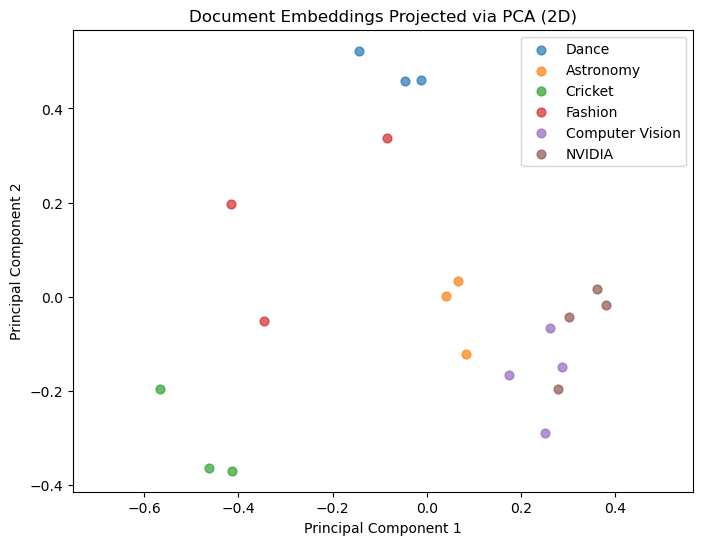

In [9]:
def plot_grid(X_projected, documents):
    fig, ax = plt.subplots(figsize=(8, 6))

    topics = []
    for doc in documents:
        if doc["topic"] not in topics:
            topics.append(doc["topic"])

    for topic in topics:
        # Find indices of documents matching this topic
        indices = []
        for i, doc in enumerate(documents):
            if doc["topic"] == topic:
                indices.append(i)

        ax.scatter(
            X_projected[indices, 0],
            X_projected[indices, 1],
            label=topic,
            alpha=0.7,
            s=40
        )

    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title("Document Embeddings Projected via PCA (2D)")
    ax.legend()
    ax.axis("equal")
    plt.show()

plot_grid(X_projected, documents)